# Actividad 3 - CNN con imágenes reales (flowers)

**Curso:** Deep Learning  
**Profesor:** Gonzalo A. Ruz  
**Ayudante:** Anthony D. Cho  

En esta actividad trabajaremos con un dataset de imágenes reales de flores y construiremos una **red neuronal convolucional (CNN)** en Keras.

## Objetivos
- Cargar un dataset de imágenes desde carpetas.
- Crear conjuntos de entrenamiento y validación.
- Construir una CNN básica para clasificación multiclase.
- Entrenar el modelo y observar su desempeño.
- Reflexionar sobre el uso de CNN en imágenes reales.

## Instrucciones
- La actividad debe ser realizada por los grupos de trabajo
- Responda cada pregunta en las celdas correspondientes
- Justifique brevemente sus respuestas cuando se solicite
- Puede reutilizar código visto en clases
- Renombrar el archivo agregando el apellido de las y los integrantes, por ejemplo actividad3_Tupper_Tudor_Gorosito_Acosta.ipynb
- Subir el archivo al link de entrega Actividad 3 en webcursos que será habilitado
- __Fecha de entrega:__ Idealmente al final del bloque 2 de la clase del 06 de abril 2026. Fecha límite de entrega 13 de abril 2026

> **Importante:** en esta actividad trabajaremos con imágenes reales, por lo que el entrenamiento puede tardar un poco más que en Fashion-MNIST.

## Integrantes (RUT – Nombre y apellido):

- 13.307.082-6 - Álvaro Iriarte  
- 13.257.556-8 - Ricardo Lopez  
- 16.789.149-7 - Camilo Muñoz  
- 25.608.509-7 - Ranse Vidal  

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Descarga del dataset

Usaremos el dataset `flower_photos`, que contiene imágenes de distintas flores organizadas en carpetas por clase.

In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)

data_dir = os.path.join(data_dir, "flower_photos")

print("Ruta del dataset:", data_dir)
print("Contenido:", os.listdir(data_dir))

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Ruta del dataset: /root/.keras/datasets/flower_photos/flower_photos
Contenido: ['tulips', 'LICENSE.txt', 'dandelion', 'sunflowers', 'daisy', 'roses']


## Crear conjuntos de entrenamiento, validación y test

Usaremos `image_dataset_from_directory`, una función muy práctica de Keras para leer imágenes desde carpetas.

En esta actividad construiremos tres conjuntos:

- **train**: para ajustar los pesos del modelo,
- **validation**: para monitorear el entrenamiento,
- **test**: para evaluar el desempeño final.

Primero separaremos un conjunto de **test**.  
Luego, a partir del resto, construiremos **train** y **validation**.

In [3]:
img_height = 180
img_width = 180
batch_size = 32
seed = 123

In [4]:
# Primero: separar train_val (80%) y test (20%)
train_val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    label_mode="categorical"
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [5]:
class_names = train_val_ds.class_names
print("Clases:", class_names)
print("Número de clases:", len(class_names))

Clases: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Número de clases: 5


Ahora separaremos el conjunto `train_val_ds` en:

- **train_ds**
- **val_ds**

Para mantener la actividad simple, haremos esta separación a nivel de batches.

In [6]:
train_val_batches = tf.data.experimental.cardinality(train_val_ds).numpy()
val_batches = max(1, int(0.2 * train_val_batches))

val_ds = train_val_ds.take(val_batches)
train_ds = train_val_ds.skip(val_batches)

print("Número de batches en train_val:", train_val_batches)
print("Número de batches para validation:", val_batches)

Número de batches en train_val: 92
Número de batches para validation: 18


## Explorar algunas imágenes

Antes de entrenar el modelo, conviene mirar algunos ejemplos del dataset para entender mejor el problema.

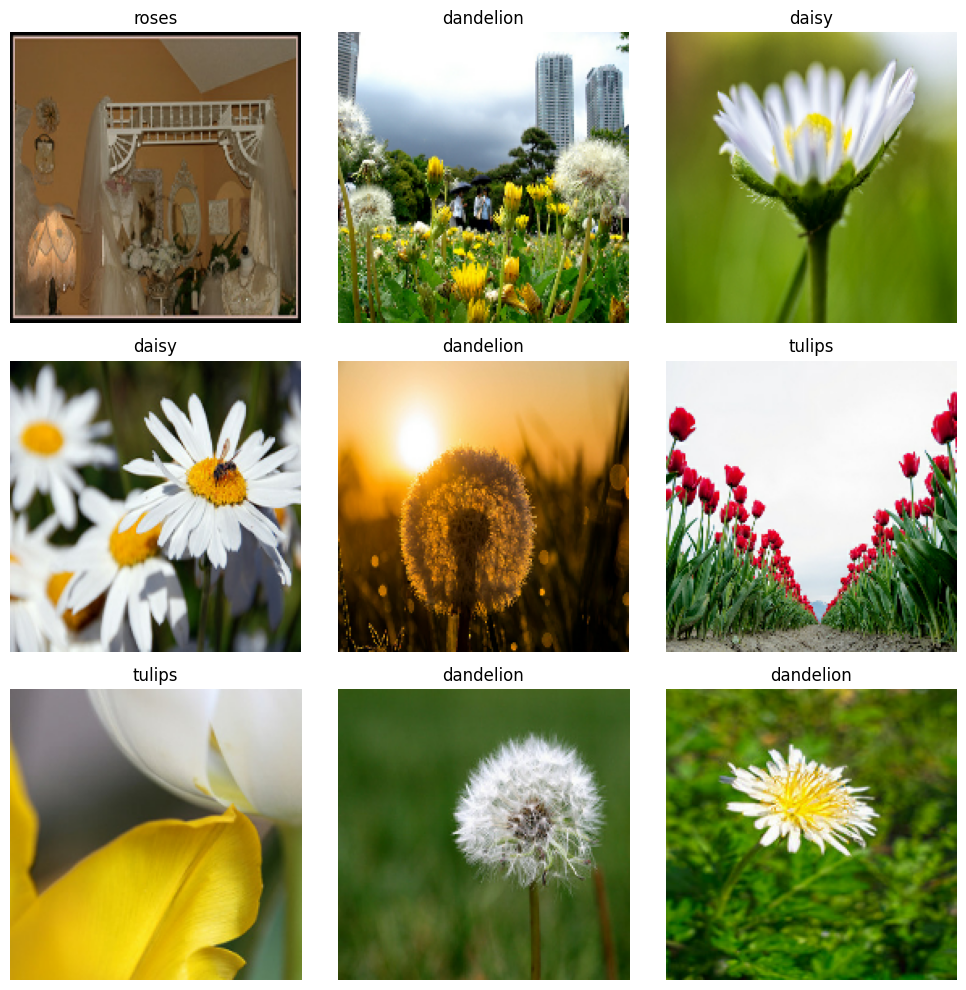

In [7]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    labels_decoded = np.argmax(labels, axis=1)
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels_decoded[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

## Preparar el pipeline

Para esta actividad haremos dos pasos simples sobre los datasets:

1. **reescalar** los valores de los píxeles de 0–255 a 0–1,
2. usar `prefetch` para que el flujo de datos sea más eficiente durante el entrenamiento.

## Reescalamiento de imágenes

Las imágenes cargadas desde carpetas suelen venir con valores entre **0 y 255**.

Para entrenar una red neuronal, normalmente conviene trabajar con valores entre **0 y 1**.


In [8]:
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
val_ds   = val_ds.map(lambda x, y: (x / 255.0, y))
test_ds  = test_ds.map(lambda x, y: (x / 255.0, y))

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

## **Pregunta 1**: Construcción de la CNN

A continuación construya una CNN básica para clasificación multiclase.

*   Complete el modelo usando su estructura propuesta:




In [10]:
model = keras.Sequential([




    ])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## **Pregunta 2**: Compilación del modelo

*   Compile el modelo:




In [11]:
model.compile(


)

## **Pregunta 3**: Entrenamiento

Entrene la CNN por pocas épocas, para que la actividad sea abordable dentro del tiempo de clase.

Entrene el modelo usando:
- `train_ds` como conjunto de entrenamiento,
- `val_ds` como conjunto de validación,
- `epochs=5`

In [12]:
history = model.fit(

)

KeyError: 'pop from an empty set'

## Curvas de entrenamiento

Ahora visualice:
- la **accuracy** de entrenamiento y validación,
- y la **loss** de entrenamiento y validación.

Estas curvas ayudan a interpretar cómo está aprendiendo el modelo.

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss durante el entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

## **Pregunta 4**: Evaluación breve

Observa las curvas anteriores y comenta brevemente:

1. ¿La accuracy de validación mejora durante el entrenamiento?
2. ¿Se observa alguna señal clara de sobreajuste?
3. ¿Cómo describirías el desempeño general del modelo?

## Evaluación final en test

Ahora evalúe el modelo en el conjunto de **test**, que quedó separado del entrenamiento y de la validación.

In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

## **Pregunta 5**: Interpretación breve

Responde brevemente:


1. ¿El desempeño en test parece consistente con lo observado en validación?


## **Pregunta 6**: Preguntas de reflexión

Responde brevemente:

1. ¿Por qué una CNN es más adecuada que un MLP para este tipo de imágenes?
2. ¿Qué función cumple `MaxPooling2D` en la arquitectura?
3. ¿Qué diferencia importante hay entre trabajar con Fashion-MNIST y trabajar con este dataset de flores?

## Cierre

En esta actividad trabajaste con un dataset de imágenes reales y entrenaste una CNN básica en Keras.

### Idea central
Aunque el pipeline es un poco más complejo que en Fashion-MNIST, la lógica general sigue siendo la misma:

- cargar datos,
- preprocesar,
- construir la CNN,
- entrenar,
- y evaluar su desempeño.

## Suerte!